In [1]:
# Unzip and list folders to verify the path
!unzip -o archive.zip
import os
print("Folders found:", os.listdir())

Archive:  archive.zip
  inflating: NEU-DET/train/annotations/crazing_163.xml  
  inflating: NEU-DET/train/annotations/crazing_164.xml  
  inflating: NEU-DET/train/annotations/crazing_165.xml  
  inflating: NEU-DET/train/annotations/crazing_166.xml  
  inflating: NEU-DET/train/annotations/crazing_167.xml  
  inflating: NEU-DET/train/annotations/crazing_168.xml  
  inflating: NEU-DET/train/annotations/crazing_169.xml  
  inflating: NEU-DET/train/annotations/crazing_17.xml  
  inflating: NEU-DET/train/annotations/crazing_170.xml  
  inflating: NEU-DET/train/annotations/crazing_171.xml  
  inflating: NEU-DET/train/annotations/crazing_172.xml  
  inflating: NEU-DET/train/annotations/crazing_173.xml  
  inflating: NEU-DET/train/annotations/crazing_174.xml  
  inflating: NEU-DET/train/annotations/crazing_175.xml  
  inflating: NEU-DET/train/annotations/crazing_176.xml  
  inflating: NEU-DET/train/annotations/crazing_177.xml  
  inflating: NEU-DET/train/annotations/crazing_178.xml  
  inflatin

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your folders are in 'NEU-DET/train'
data_dir = 'NEU-DET/train'

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(data_dir, target_size=(224, 224), batch_size=32, subset='training')
val_gen = datagen.flow_from_directory(data_dir, target_size=(224, 224), batch_size=32, subset='validation')

# IMPORTANT: This prints your actual class count
print(f"Number of classes detected: {train_gen.num_classes}")

Found 1152 images belonging to 2 classes.
Found 288 images belonging to 2 classes.
Number of classes detected: 2


In [3]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    # Use the number from the 'num_classes' printout above
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 285s 8s/step - accuracy: 0.9731 - loss: 0.0474 - val_accuracy: 1.0000 - val_loss: 1.7923e-07
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 282s 8s/step - accuracy: 1.0000 - loss: 5.2940e-07 - val_accuracy: 1.0000 - val_loss: 1.1880e-07
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 315s 8s/step - accuracy: 1.0000 - loss: 3.8836e-07 - val_accuracy: 1.0000 - val_loss: 1.1714e-07
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 273s 8s/step - accuracy: 1.0000 - loss: 3.8940e-07 - val_accuracy: 1.0000 - val_loss: 1.1259e-07
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 275s 8s/step - accuracy: 1.0000 - loss: 2.8116e-07 - val_accuracy: 1.0000 - val_loss: 2.1938e-08


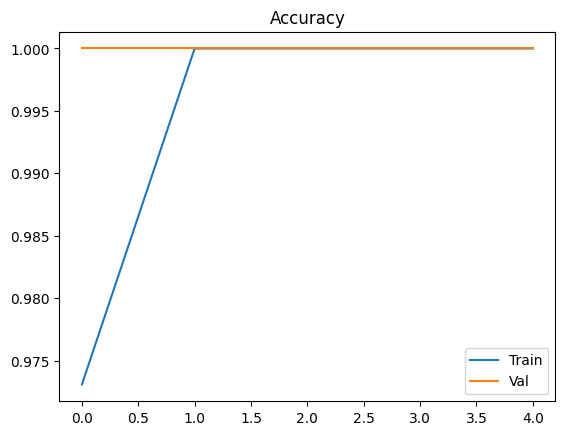

In [4]:
history = model.fit(train_gen, validation_data=val_gen, epochs=5)

import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

In [5]:
!ls -R NEU-DET/train

NEU-DET/train:
annotations  images

NEU-DET/train/annotations:
crazing_163.xml    patches_144.xml	    rolled-in_scale_122.xml
crazing_164.xml    patches_145.xml	    rolled-in_scale_123.xml
crazing_165.xml    patches_146.xml	    rolled-in_scale_124.xml
crazing_166.xml    patches_147.xml	    rolled-in_scale_125.xml
crazing_167.xml    patches_148.xml	    rolled-in_scale_126.xml
crazing_168.xml    patches_149.xml	    rolled-in_scale_127.xml
crazing_169.xml    patches_14.xml	    rolled-in_scale_128.xml
crazing_170.xml    patches_150.xml	    rolled-in_scale_129.xml
crazing_171.xml    patches_151.xml	    rolled-in_scale_12.xml
crazing_172.xml    patches_152.xml	    rolled-in_scale_130.xml
crazing_173.xml    patches_153.xml	    rolled-in_scale_131.xml
crazing_174.xml    patches_154.xml	    rolled-in_scale_132.xml
crazing_175.xml    patches_155.xml	    rolled-in_scale_133.xml
crazing_176.xml    patches_156.xml	    rolled-in_scale_134.xml
crazing_177.xml    patches_157.xml	    rolled-in_scale_13

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# If 'ls -R' shows images in 'NEU-DET/train/images', use the line below:
data_dir = 'NEU-DET/train/images'

# Setup the generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# This will print the number of classes. USE THIS NUMBER in your final model layer!
print(f"Detected {train_gen.num_classes} classes.")

Found 1152 images belonging to 6 classes.
Detected 6 classes.


In [7]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    # Use the number from the printout (e.g., if it says 6, use 6)
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])